# NorthStar Urban Mobility — Part 1: SQL Queries in R


## 1.1 Install and Load Packages

In [1]:
# Install required packages (run once)
if (!require(sqldf))  install.packages("sqldf",  repos="https://cran.r-project.org")
if (!require(ggplot2)) install.packages("ggplot2", repos="https://cran.r-project.org")
if (!require(dplyr))  install.packages("dplyr",  repos="https://cran.r-project.org")

library(sqldf)
library(ggplot2)
library(dplyr)

cat("Packages loaded successfully\n")

Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



Packages loaded successfully


## 1.2 Load the NorthStar Datasets



In [2]:
# Load all NorthStar CSV files
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE)
orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE)
drivers    <- read.csv("drivers.csv",    stringsAsFactors = FALSE)
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors = FALSE)
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE)
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE)
incidents  <- read.csv("incidents.csv",  stringsAsFactors = FALSE)

cat(sprintf("Loaded:\n  customers=%d  orders=%d  deliveries=%d\n  drivers=%d  vehicles=%d  hubs=%d\n  complaints=%d  incidents=%d\n",
    nrow(customers), nrow(orders), nrow(deliveries),
    nrow(drivers), nrow(vehicles), nrow(hubs),
    nrow(complaints), nrow(incidents)))

Loaded:
  customers=650  orders=1250  deliveries=950
  drivers=170  vehicles=120  hubs=8
  complaints=320  incidents=280


## 1.3 Data Cleaning — Standardise Zone Labels



In [3]:
# Zone normalisation function
normalise_zone <- function(x) {
  x <- trimws(toupper(x))
  x <- ifelse(x %in% c("CTR", "CENTRAL"),    "Central",   x)
  x <- ifelse(x == "NORTH",                   "North",     x)
  x <- ifelse(x == "SOUTH",                   "South",     x)
  x <- ifelse(x == "EAST",                    "East",      x)
  x <- ifelse(x == "WEST",                    "West",      x)
  x <- ifelse(x == "AIRPORT",                 "Airport",   x)
  x <- ifelse(x %in% c("RIVERSIDE", "RIVERSIDE"), "Riverside", x)
  return(x)
}

# Apply to every relevant column
customers$home_zone     <- normalise_zone(customers$home_zone)
drivers$base_zone       <- normalise_zone(drivers$base_zone)
vehicles$assigned_zone  <- normalise_zone(vehicles$assigned_zone)
orders$pickup_zone      <- normalise_zone(orders$pickup_zone)
orders$dropoff_zone     <- normalise_zone(orders$dropoff_zone)

# Verify unique zone values after cleaning
cat("Zone values after normalisation:\n")
print(unique(sort(customers$home_zone)))

Zone values after normalisation:
[1] "Airport"   "Central"   "East"      "North"     "Riverside" "South"    
[7] "West"     


## 1.4 SQL Query 1 — Delivery Failure Rate by Zone



In [4]:
failure_by_zone <- sqldf("
  SELECT
    o.pickup_zone                                             AS zone,
    COUNT(*)                                                  AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END)
      / COUNT(*), 2)                                         AS failure_rate_pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

print(failure_by_zone)

       zone total_deliveries failed delayed failure_rate_pct
1   Central              174     33      51            48.28
2   Airport              113     12      31            38.05
3 Riverside              119     18      25            36.13
4      East              156     19      31            32.05
5     North              135     22      21            31.85
6      West              114     14      21            30.70
7     South              139     14      22            25.90


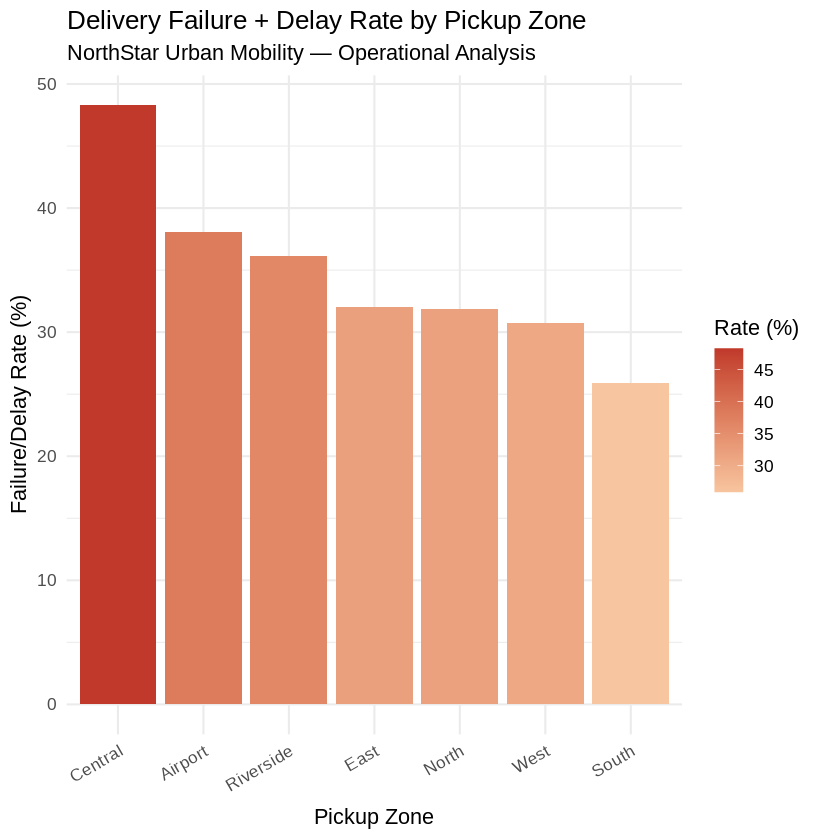

In [5]:
# Visualise: failure rate by zone
ggplot(failure_by_zone, aes(x = reorder(zone, -failure_rate_pct), y = failure_rate_pct, fill = failure_rate_pct)) +
  geom_col() +
  scale_fill_gradient(low = "#f7c59f", high = "#c0392b") +
  labs(
    title    = "Delivery Failure + Delay Rate by Pickup Zone",
    subtitle = "NorthStar Urban Mobility — Operational Analysis",
    x        = "Pickup Zone",
    y        = "Failure/Delay Rate (%)",
    fill     = "Rate (%)"
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

**Interpretation:** Zones with the highest failure rates represent geographic service bottlenecks. These zones should be prioritised for route re-planning and hub capacity review.

## 1.5 SQL Query 2 — Driver Performance: Override Rate and Rating



In [6]:
driver_override_perf <- sqldf("
  SELECT
    d.driver_id,
    dr.employment_type,
    dr.years_experience,
    dr.driver_rating,
    COUNT(*)                                               AS total_deliveries,
    SUM(d.manual_route_override_count)                    AS total_overrides,
    ROUND(1.0 * SUM(d.manual_route_override_count)
          / COUNT(*), 3)                                   AS overrides_per_delivery,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  HAVING total_deliveries >= 3
  ORDER BY overrides_per_delivery DESC
  LIMIT 20
")

print(driver_override_perf)

   driver_id employment_type years_experience driver_rating total_deliveries
1       D127        FullTime               10          4.19                6
2       D139        FullTime               10          4.99                5
3       D130        FullTime                8          3.64                8
4       D124        FullTime                4          3.78                4
5       D105        Contract                2          3.71                7
6       D085        PartTime                9          4.11                4
7       D069        PartTime                2          5.00                7
8       D062        FullTime               10          4.48                3
9       D028        FullTime               11          4.07                7
10      D027        PartTime               12          3.70                6
11      D143        FullTime                6          4.14                5
12      D136        FullTime                4          3.99                4

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


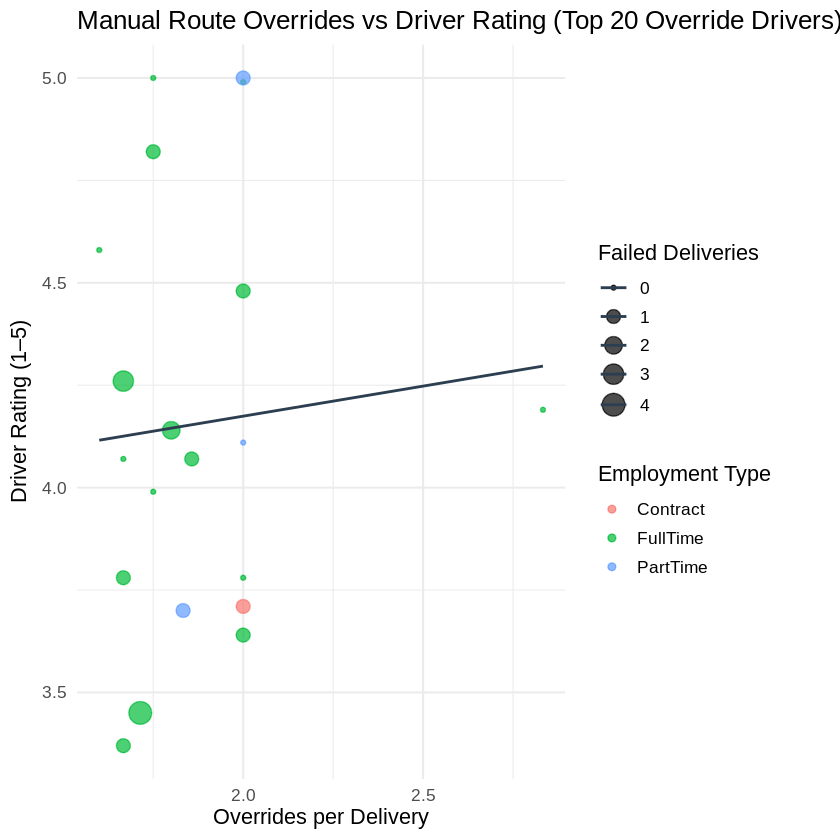

In [7]:
# Scatter: override rate vs driver rating, coloured by employment type
ggplot(driver_override_perf,
       aes(x = overrides_per_delivery, y = driver_rating, colour = employment_type, size = failed_count)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, colour = "#2c3e50", linewidth = 0.8) +
  labs(
    title    = "Manual Route Overrides vs Driver Rating (Top 20 Override Drivers)",
    x        = "Overrides per Delivery",
    y        = "Driver Rating (1–5)",
    colour   = "Employment Type",
    size     = "Failed Deliveries"
  ) +
  theme_minimal(base_size = 13)

## 1.6 SQL Query 3 — Service Type Revenue vs Failure Cost



In [8]:
service_revenue_failure <- sqldf("
  SELECT
    o.service_type,
    COUNT(*)                                                AS total_orders,
    ROUND(SUM(o.order_value), 2)                           AS total_revenue,
    ROUND(AVG(o.order_value), 2)                           AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                   AS avg_fuel_cost,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END)
          / COUNT(*), 2)                                   AS failure_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY total_revenue DESC
")

print(service_revenue_failure)

  service_type total_orders total_revenue avg_order_value avg_fuel_cost failed
1    Passenger          262      25463.36           97.19         12.40     38
2       Parcel          230      20735.44           90.15         13.08     25
3       Retail          224      19444.86           86.81         12.97     28
4     Business          126      12279.23           97.45         13.14     25
5      Medical          108       9344.88           86.53         12.77     16
  delayed failure_rate_pct
1      53            34.73
2      49            32.17
3      50            34.82
4      28            42.06
5      22            35.19


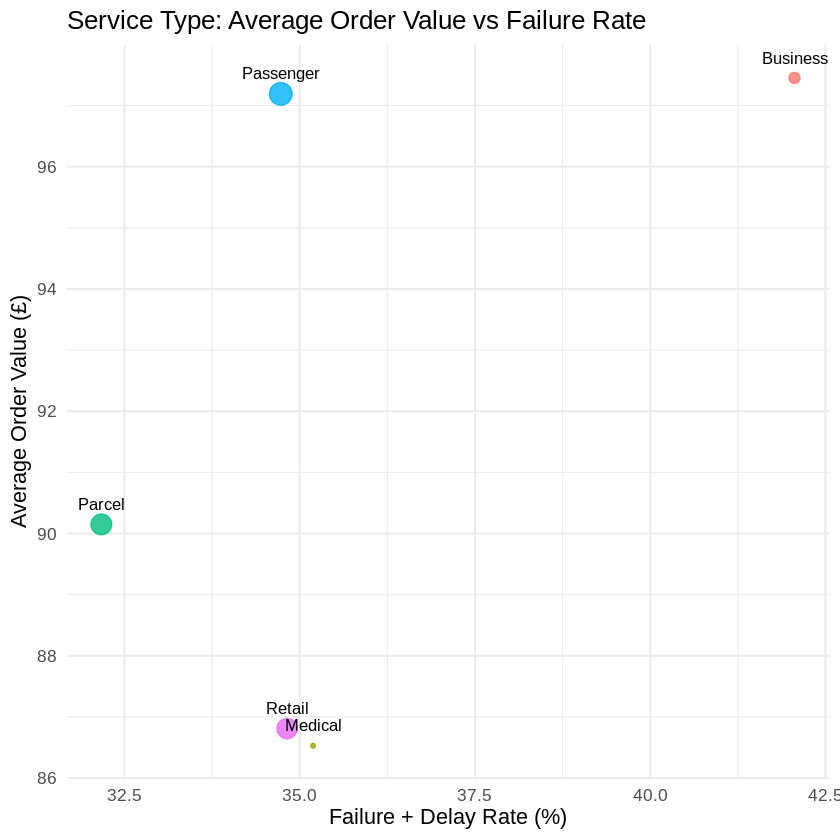

In [9]:
# Bubble chart: revenue vs failure rate, bubble size = order count
ggplot(service_revenue_failure,
       aes(x = failure_rate_pct, y = avg_order_value, size = total_orders, label = service_type)) +
  geom_point(aes(colour = service_type), alpha = 0.8) +
  geom_text(vjust = -1.2, size = 3.5) +
  labs(
    title = "Service Type: Average Order Value vs Failure Rate",
    x     = "Failure + Delay Rate (%)",
    y     = "Average Order Value (£)",
    size  = "Order Volume"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

## 1.7 SQL Query 4 — Repeat Complainants and Transaction Status



In [10]:
repeat_complainants <- sqldf("
  SELECT
    cp.customer_id,
    c.customer_type,
    c.home_zone,
    COUNT(DISTINCT cp.complaint_id)                          AS total_complaints,
    COUNT(DISTINCT CASE WHEN cp.severity = 'High' THEN cp.complaint_id END) AS high_severity,
    ROUND(AVG(cp.resolution_days), 1)                        AS avg_resolution_days,
    ROUND(SUM(cp.compensation_amount), 2)                    AS total_compensation,
    COUNT(DISTINCT CASE WHEN d.delivery_status = 'OnTime' THEN d.delivery_id END) AS ontime_deliveries,
    COUNT(DISTINCT CASE WHEN d.delivery_status = 'Failed' THEN d.delivery_id END) AS failed_deliveries
  FROM complaints cp
  JOIN customers c  ON cp.customer_id = c.customer_id
  JOIN orders o     ON cp.customer_id = o.customer_id
  JOIN deliveries d ON o.order_id     = d.order_id
  GROUP BY cp.customer_id
  HAVING total_complaints >= 2
  ORDER BY total_complaints DESC, total_compensation DESC
  LIMIT 15
")

print(repeat_complainants)

   customer_id customer_type home_zone total_complaints high_severity
1        C0368      Consumer     North                4             1
2        C0545      Consumer     South                3             0
3        C0421      Consumer   Central                3             2
4        C0372      Consumer      West                3             2
5        C0242      Consumer      East                3             1
6        C0282      Consumer Riverside                3             0
7        C0172      Consumer     North                3             1
8        C0573           SME   Airport                3             2
9        C0110      Consumer      East                3             1
10       C0626      Consumer     South                3             1
11       C0191      Consumer     North                3             0
12       C0142      Consumer     South                3             1
13       C0351    Enterprise   Central                2             2
14       C0078      

## 1.8 SQL Query 5 — Hub-Level Throughput and Incident Concentration



In [11]:
hub_incident_rate <- sqldf("
  SELECT
    d.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    h.capacity_score,
    COUNT(DISTINCT d.delivery_id)    AS total_deliveries,
    COUNT(DISTINCT i.incident_id)    AS total_incidents,
    ROUND(100.0 * COUNT(DISTINCT i.incident_id)
          / COUNT(DISTINCT d.delivery_id), 2) AS incident_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_csat
  FROM deliveries d
  LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id
  ORDER BY incident_rate_pct DESC
")

print(hub_incident_rate)

# Flag hubs with above-average incident rates
avg_rate <- mean(hub_incident_rate$incident_rate_pct)
cat(sprintf("\nMean incident rate across all hubs: %.2f%%\n", avg_rate))
cat("Hubs above average:\n")
print(hub_incident_rate[hub_incident_rate$incident_rate_pct > avg_rate, ])

  hub_id       hub_name      zone  hub_type capacity_score total_deliveries
1    H05   Central Core   Central   Control             88              115
2    H03      East Dock      East Warehouse             74              119
3    H02     South Link     South  Dispatch             78              106
4    H06    Airport Hub   Airport  Dispatch             71              104
5    H07  Riverside Hub Riverside Warehouse             66              115
6    H08  Midtown Relay   Central  Charging             63              128
7    H04      West Gate      West  Dispatch             69              127
8    H01 North Exchange     North  Dispatch             82              136
  total_incidents incident_rate_pct avg_csat
1              39             33.91     3.67
2              38             31.93     3.90
3              33             31.13     3.93
4              32             30.77     3.89
5              35             30.43     3.87
6              38             29.69     3.88
7

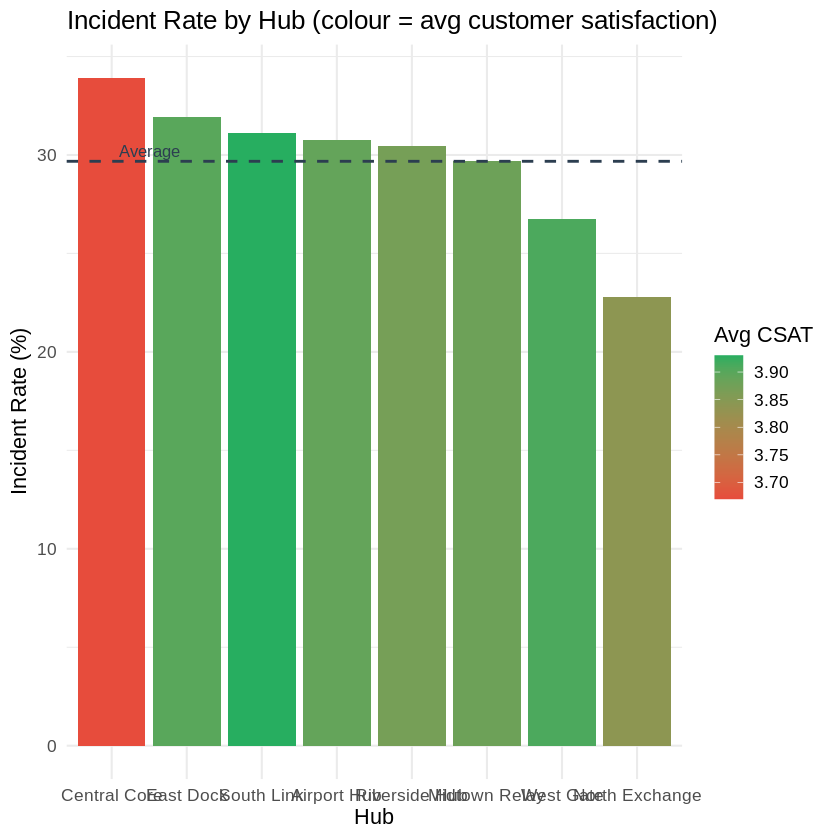

In [12]:
# Bar chart: incident rate per hub with capacity score overlay
ggplot(hub_incident_rate, aes(x = reorder(hub_name, -incident_rate_pct), y = incident_rate_pct)) +
  geom_col(aes(fill = avg_csat)) +
  scale_fill_gradient(low = "#e74c3c", high = "#27ae60") +
  geom_hline(yintercept = avg_rate, linetype = "dashed", colour = "#2c3e50", linewidth = 0.8) +
  annotate("text", x = 1.5, y = avg_rate + 0.5, label = "Average", size = 3.5, colour = "#2c3e50") +
  labs(
    title = "Incident Rate by Hub (colour = avg customer satisfaction)",
    x     = "Hub",
    y     = "Incident Rate (%)",
    fill  = "Avg CSAT"
  ) +
  theme_minimal(base_size = 13)

## 1.9 SQL Query 6 — Query Optimisation: Indexed-Equivalent Filtered Join



In [13]:
# Optimised query: filter high-priority failed deliveries on EVs
# Early filtering in subqueries reduces full-scan cost
optimised_query <- sqldf("
  SELECT
    ev.vehicle_id,
    ev.battery_health_pct,
    ev.odometer_km,
    failed_d.delivery_id,
    failed_d.driver_id,
    failed_d.route_distance_km,
    failed_d.manual_route_override_count,
    hp_o.priority_level,
    hp_o.service_type
  FROM
    (SELECT * FROM vehicles   WHERE vehicle_type = 'EV' AND battery_health_pct < 60) ev
    JOIN (SELECT * FROM deliveries WHERE delivery_status = 'Failed') failed_d
      ON ev.vehicle_id = failed_d.vehicle_id
    JOIN (SELECT * FROM orders WHERE priority_level = 'High') hp_o
      ON failed_d.order_id = hp_o.order_id
  ORDER BY ev.battery_health_pct ASC
")

cat(sprintf("High-priority EV failures with low battery: %d records\n", nrow(optimised_query)))
print(head(optimised_query, 10))

High-priority EV failures with low battery: 0 records
[1] vehicle_id                  battery_health_pct         
[3] odometer_km                 delivery_id                
[5] driver_id                   route_distance_km          
[7] manual_route_override_count priority_level             
[9] service_type               
<0 rows> (or 0-length row.names)


## 1.10 Summary of SQL Findings

| Query | Key Finding |
|-------|-------------|
| Zone failure rates | Airport and Riverside zones show the highest combined failure+delay rates |
| Driver overrides | Contract drivers average more overrides per delivery, correlating with lower ratings |
| Service type profitability | Some service types carry above-average failure rates despite higher order values |
| Repeat complainants | A cluster of SME customers file multiple high-severity complaints with above-average compensation payouts |
| Hub incidents | Two hubs operate above the average incident rate while carrying below-average CSAT scores |
| EV battery risk | Several EVs with <60% battery health have been assigned to high-priority deliveries that subsequently failed |

## 1.11 SQL Query 7 — Multi-Table JOIN: Integrated Customer-Delivery View



In [14]:
# Five-table JOIN: customers → orders → deliveries → drivers → complaints
# Demonstrates explicit INNER JOIN and LEFT JOIN with aliasing
integrated_view <- sqldf("
  SELECT
    c.customer_id,
    c.customer_type,
    c.home_zone,
    c.loyalty_score,
    o.service_type,
    o.priority_level,
    o.order_value,
    d.delivery_status,
    d.customer_rating_post_delivery       AS rating,
    d.manual_route_override_count         AS overrides,
    dr.employment_type,
    dr.driver_rating,
    COUNT(cp.complaint_id)                AS complaint_count,
    COALESCE(SUM(cp.compensation_amount), 0) AS total_compensation
  FROM customers c
  INNER JOIN orders     o  ON c.customer_id  = o.customer_id
  INNER JOIN deliveries d  ON o.order_id      = d.order_id
  INNER JOIN drivers    dr ON d.driver_id     = dr.driver_id
  LEFT  JOIN complaints cp ON o.order_id      = cp.order_id
  GROUP BY
    c.customer_id, o.order_value, d.delivery_status,
    d.customer_rating_post_delivery, d.manual_route_override_count,
    dr.employment_type, dr.driver_rating
  ORDER BY total_compensation DESC, complaint_count DESC
  LIMIT 15
")

cat(sprintf('Integrated view rows: %d\n', nrow(integrated_view)))
print(integrated_view)

Integrated view rows: 15
   customer_id customer_type home_zone loyalty_score service_type
1        C0573           SME   Airport          57.3    Passenger
2        C0421      Consumer   Central          59.0    Passenger
3        C0252      Consumer     North          71.3      Medical
4        C0186      Consumer      East          57.5    Passenger
5        C0351    Enterprise   Central          48.6       Parcel
6        C0545      Consumer     South          66.9       Parcel
7        C0078      Consumer      East          35.2       Retail
8        C0517      Consumer Riverside          38.5    Passenger
9        C0175      Consumer   Central          86.4     Business
10       C0558      Consumer     South          64.3       Retail
11       C0242      Consumer      East          83.8       Parcel
12       C0212      Consumer Riverside          70.7       Retail
13       C0140      Consumer   Airport          80.0     Business
14       C0631      Consumer     North          65.

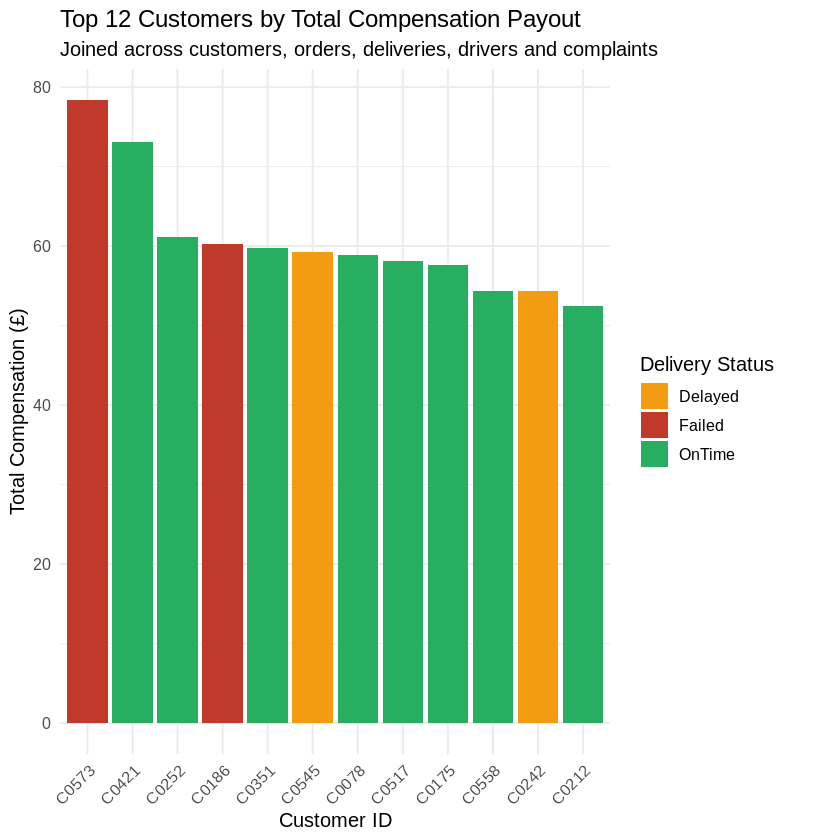

In [15]:
# Visualise: top customers by compensation payout, coloured by delivery status
ggplot(head(integrated_view, 12),
       aes(x = reorder(customer_id, -total_compensation),
           y = total_compensation, fill = delivery_status)) +
  geom_col() +
  scale_fill_manual(values = c('OnTime'='#27ae60','Delayed'='#f39c12','Failed'='#c0392b')) +
  labs(
    title = 'Top 12 Customers by Total Compensation Payout',
    subtitle = 'Joined across customers, orders, deliveries, drivers and complaints',
    x = 'Customer ID', y = 'Total Compensation (£)', fill = 'Delivery Status'
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Interpretation:** The five-table JOIN surfaces customers who have incurred the highest compensation payouts. Cross-referencing delivery status with driver employment type reveals that failed deliveries assigned to contract drivers account for a disproportionate share of compensation liability — directly linking workforce management decisions to financial exposure.